In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os

In [2]:
sys.path.append(os.path.abspath('../..')) 
from src.xai.xai_baseExplainer import BaseExplainer

model_path = "../../models/best_models_cnn_lstm/best_cnn_lstm_FD001.keras"
x_path = "../../data/processed_data/X_test_FD001.npz"
y_path = "../../data/processed_data/y_test_FD001.npz"

#Inicia a classe Base
base = BaseExplainer(model_path, x_path, y_path)

## Testando se as funções estão funcionando.

In [3]:
indice = 0

print(f"--- TESTE: AMOSTRA {indice} ---")
print(f"Shape retornado: {base.get_instance(indice).shape}")
print(f"RUL Real: {base.get_true_rul(indice)}")
print(f"RUL Predito: {base.get_prediction(indice):.2f}")

--- TESTE: AMOSTRA 0 ---
Shape retornado: (1, 30, 19)
RUL Real: 113
RUL Predito: 120.95


## ShapExplainer

In [4]:
from src.xai.xai_shapExplainer import ShapExplainer

model_path = "../../models/best_models_cnn_lstm/best_cnn_lstm_FD001.keras"
x_path = "../../data/processed_data/X_test_FD001.npz"
y_path = "../../data/processed_data/y_test_FD001.npz"

explainer_shap = ShapExplainer(model_path, x_path, y_path)

In [5]:
idx_amostra = 0
print(f"Calculando SHAP para a amostra {idx_amostra}...")
shap_values = explainer_shap.explain_instance(idx_amostra)

print(f"RUL Real: {explainer_shap.get_true_rul(idx_amostra)}")
print(f"RUL Previsto: {explainer_shap.get_prediction(idx_amostra):.2f}")
print(f"Shape original dos SHAP values: {shap_values.shape}")

Calculando SHAP para a amostra 0...


C:\Users\davis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_30
Received: inputs=['Tensor(shape=(1, 30, 19))']
  warnings.warn(msg)
C:\Users\davis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_30
Received: inputs=['Tensor(shape=(50, 30, 19))']
  warnings.warn(msg)


RUL Real: 113
RUL Previsto: 120.95
Shape original dos SHAP values: (1, 30, 19, 1)


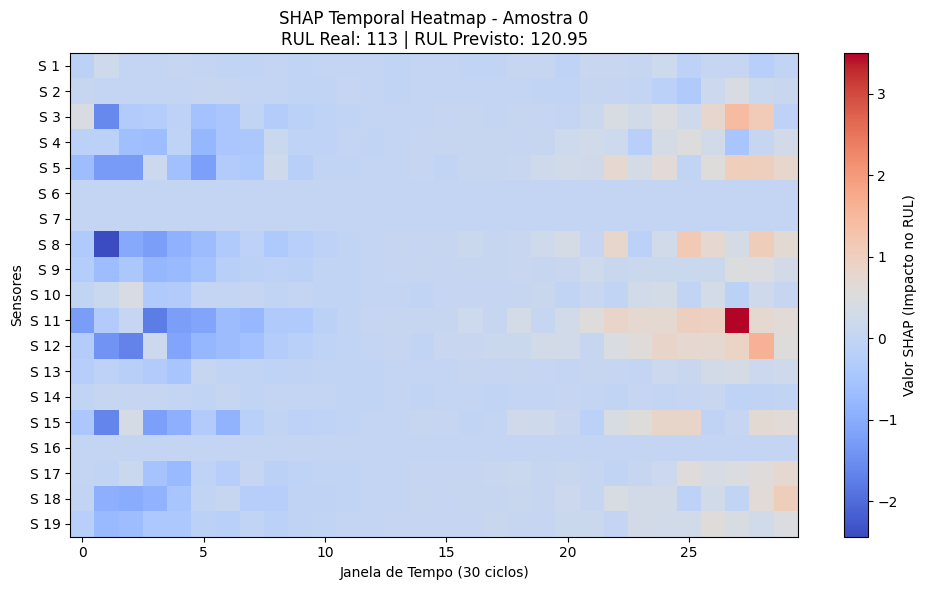

In [6]:
explainer_shap.plot_temporal_heatmap(idx_amostra)

C:\Users\davis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_30
Received: inputs=['Tensor(shape=(1, 30, 19))']
  warnings.warn(msg)


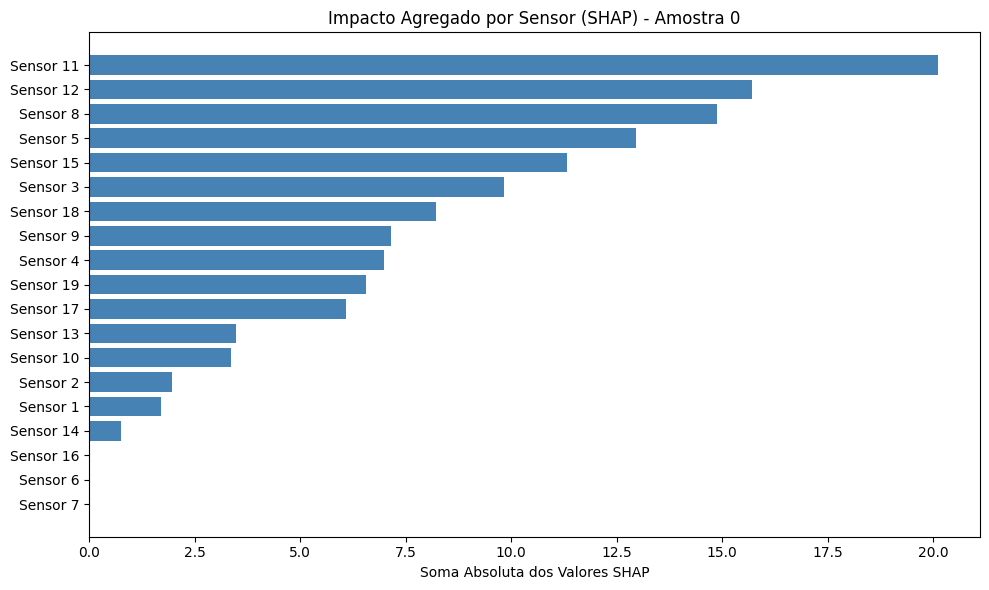

In [7]:
explainer_shap.plot_sensor_importance_bar(idx_amostra)

Calculando SHAP para 100 amostras (isso pode levar alguns segundos)...


C:\Users\davis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_30
Received: inputs=['Tensor(shape=(100, 30, 19))']
  warnings.warn(msg)
c:\Users\davis\Documents\vscode\Turbofan-Engine-Degradation-Mestrado\src\xai\xai_shapExplainer.py:82: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_2d, instances_2d, feature_names=sensores_labels, show=False)


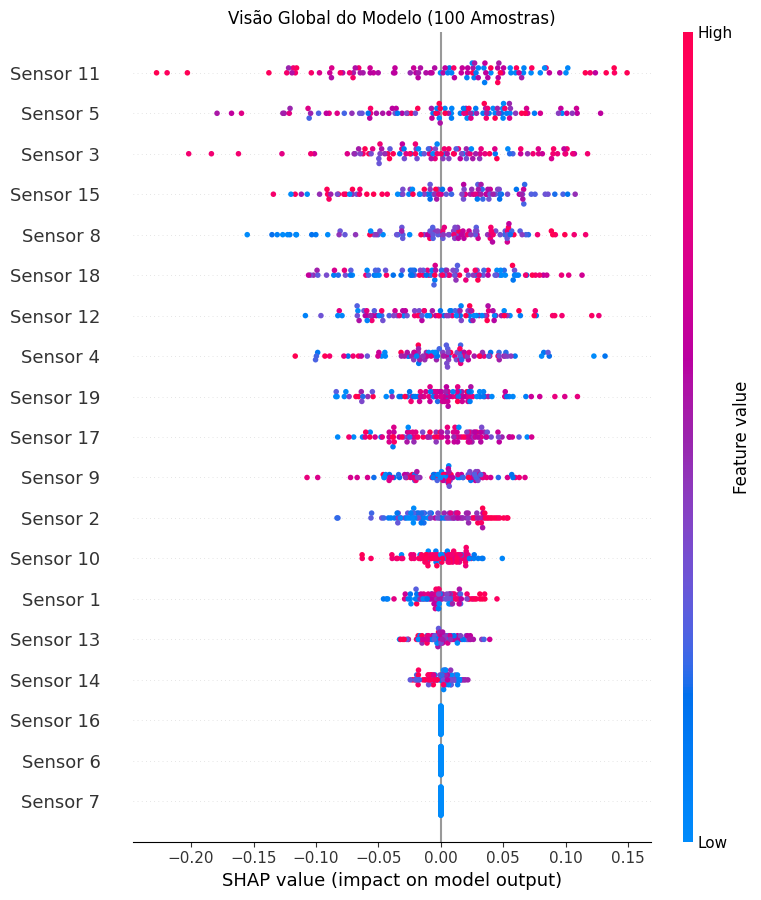

In [8]:
# Testa a visão global com as primeiras 50 máquinas
explainer_shap.plot_global_summary()